## <초기 세팅>

## 한글 깨짐 방지

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

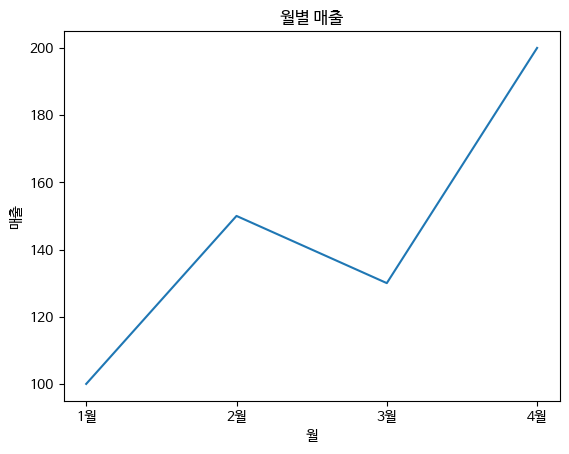

In [3]:
# 테스트 그래프
# 런타임 -> 세션 다시 시작 및 모두 실행

import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    '월': ['1월', '2월', '3월', '4월'],
    '매출': [100, 150, 130, 200]
})

sns.lineplot(data=df, x='월', y='매출')
plt.title('월별 매출')
plt.show()

## 파일 불러오기

In [10]:
from google.colab import files

uploaded = files.upload()
'''
Saving 1.address.txt to 1.address.txt
Saving 2.customer.txt to 2.customer.txt
Saving 3.item.txt to 3.item.txt
Saving 4.reservation.txt to 4.reservation.txt
Saving 5.order_info.txt to 5.order_info.txt
-> 이렇게 뜨면 성공
'''

Saving 5.order_info.txt to 5.order_info.txt
Saving 4.reservation.txt to 4.reservation.txt
Saving 3.item.txt to 3.item.txt
Saving 2.customer.txt to 2.customer.txt
Saving 1.address.txt to 1.address.txt


'\nSaving 1.address.txt to 1.address.txt\nSaving 2.customer.txt to 2.customer.txt\nSaving 3.item.txt to 3.item.txt\nSaving 4.reservation.txt to 4.reservation.txt\nSaving 5.order_info.txt to 5.order_info.txt\n-> 이렇게 뜨면 성공\n'

## SQL 사용하기

In [11]:
import re
import pandas as pd
import sqlite3

In [12]:
def parse_insert_file(file_path, columns):
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    pattern = r"values\s*\((.*?)\);"

    for match in re.findall(pattern, text, flags=re.IGNORECASE):
        # 작은따옴표 안 콤마는 없는 데이터라 간단 split 가능
        values = []
        current = ""
        in_quote = False

        for ch in match:
            if ch == "'":
                in_quote = not in_quote
                continue

            if ch == "," and not in_quote:
                values.append(current.strip())
                current = ""
            else:
                values.append(ch) if False else None
                current += ch

        values.append(current.strip())

        # null 처리
        values = [None if v.lower() == "null" else v for v in values]
        rows.append(values)

    return pd.DataFrame(rows, columns=columns)

In [13]:
def split_values(s):
    values = []
    current = ""
    in_quote = False
    paren_depth = 0

    for ch in s:
        if ch == "'":
            in_quote = not in_quote
            current += ch

        elif ch == "(" and not in_quote:
            paren_depth += 1
            current += ch

        elif ch == ")" and not in_quote:
            paren_depth -= 1
            current += ch

        elif ch == "," and not in_quote and paren_depth == 0:
            values.append(current.strip())
            current = ""

        else:
            current += ch

    values.append(current.strip())
    return values


def clean_value(v):
    v = v.strip()

    if v.lower() == "null":
        return None

    # Oracle to_date('2017-09-01 00:00:00','YYYY-MM-DD HH24:MI:SS') 처리
    m = re.match(r"to_date\('([^']+)'", v, flags=re.IGNORECASE)
    if m:
        return m.group(1)

    # 문자열 따옴표 제거
    if len(v) >= 2 and v[0] == "'" and v[-1] == "'":
        return v[1:-1]

    return v


def parse_insert_file(file_path, columns):
    rows = []

    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    pattern = r"values\s*\((.*?)\);"

    for match in re.findall(pattern, text, flags=re.IGNORECASE | re.DOTALL):
        values = split_values(match)
        values = [clean_value(v) for v in values]

        if len(values) != len(columns):
            print("컬럼 개수 안 맞음:", file_path)
            print("expected:", len(columns), "actual:", len(values))
            print(values)
            break

        rows.append(values)

    return pd.DataFrame(rows, columns=columns)

In [14]:
address = parse_insert_file(
    "1.address.txt",
    ["ZIP_CODE", "ADDRESS_DETAIL"]
)

customer = parse_insert_file(
    "2.customer.txt",
    ["CUSTOMER_ID", "CUSTOMER_NAME", "PHONE_NUMBER", "EMAIL",
     "FIRST_REG_DATE", "SEX_CODE", "BIRTH", "JOB", "ZIP_CODE"]
)

item = parse_insert_file(
    "3.item.txt",
    ["ITEM_ID", "PRODUCT_NAME", "PRODUCT_DESC", "CATEGORY_ID", "PRICE"]
)

reservation = parse_insert_file(
    "4.reservation.txt",
    ["RESERV_NO", "RESERV_DATE", "RESERV_TIME", "CUSTOMER_ID",
     "BRANCH", "VISITOR_CNT", "CANCEL"]
)

order_info = parse_insert_file(
    "5.order_info.txt",
    ["ORDER_NO", "ITEM_ID", "RESERV_NO", "QUANTITY", "SALES"]
)

In [15]:
# 확인
print(address.shape)
print(customer.shape)
print(item.shape)
print(reservation.shape)
print(order_info.shape)

(25, 2)
(183, 9)
(10, 5)
(396, 7)
(391, 5)


In [16]:
# 숫자 변환
item["PRICE"] = pd.to_numeric(item["PRICE"])
reservation["VISITOR_CNT"] = pd.to_numeric(reservation["VISITOR_CNT"])
order_info["QUANTITY"] = pd.to_numeric(order_info["QUANTITY"])
order_info["SALES"] = pd.to_numeric(order_info["SALES"])

In [17]:
# SQLite 넣기
conn = sqlite3.connect(":memory:")

address.to_sql("ADDRESS", conn, index=False, if_exists="replace")
customer.to_sql("CUSTOMER", conn, index=False, if_exists="replace")
item.to_sql("ITEM", conn, index=False, if_exists="replace")
reservation.to_sql("RESERVATION", conn, index=False, if_exists="replace")
order_info.to_sql("ORDER_INFO", conn, index=False, if_exists="replace")

391

In [18]:
# SQL 실행 테스트
query = """
SELECT
    I.PRODUCT_NAME,
    SUM(O.SALES) AS SALES_SUM
FROM ORDER_INFO O
JOIN ITEM I
    ON O.ITEM_ID = I.ITEM_ID
GROUP BY I.PRODUCT_NAME
ORDER BY SALES_SUM DESC
"""

df = pd.read_sql(query, conn)
df

,PRODUCT_NAME,SALES_SUM
0,STEAK,9380000
1,SPECIAL_SET,5808000
2,SALAD_BAR,2075000
3,PASTA,1968000
4,PIZZA,1666000
5,SEA_FOOD,1625000
6,WINE,856000
7,SANDWICH,610000
8,SALAD,525000
9,JUICE,444000


## 3번 SQL

In [19]:
query = """
SELECT
    COUNT(*) AS 총주문건,
    SUM(O.SALES) AS 총매출합계,

    COUNT(CASE
            WHEN I.PRODUCT_DESC = '온라인_전용상품'
            THEN 1
          END) AS 온라인전용주문건,

    SUM(CASE
            WHEN I.PRODUCT_DESC = '온라인_전용상품'
            THEN O.SALES
            ELSE 0
        END) AS 온라인전용매출합계,

    ROUND(
        COUNT(CASE
                WHEN I.PRODUCT_DESC = '온라인_전용상품'
                THEN 1
              END)
        * 100.0 / COUNT(*)
    , 2) AS 주문건수비율,

    ROUND(
        SUM(CASE
                WHEN I.PRODUCT_DESC = '온라인_전용상품'
                THEN O.SALES
                ELSE 0
            END)
        * 100.0 / SUM(O.SALES)
    , 2) AS 매출합계비율

FROM ORDER_INFO O
JOIN ITEM I
    ON O.ITEM_ID = I.ITEM_ID
WHERE O.RESERV_NO IS NOT NULL
"""

df = pd.read_sql(query, conn)

df

,총주문건,총매출합계,온라인전용주문건,온라인전용매출합계,주문건수비율,매출합계비율
0,391,24957000,59,5808000,15.09,23.27


### 온라인 전용상품 주문건수 비율

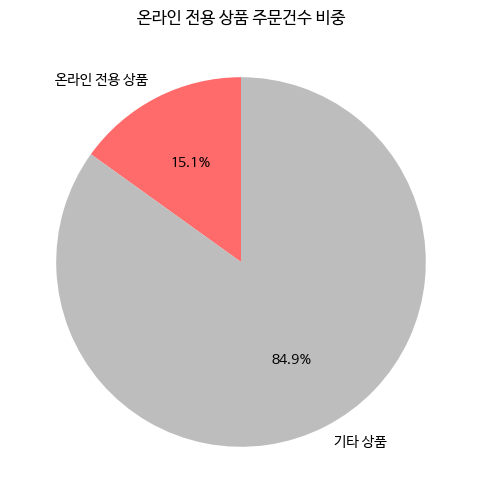

In [20]:
online_orders = df.loc[0, '온라인전용주문건']
etc_orders = df.loc[0, '총주문건'] - online_orders

plt.figure(figsize=(6, 6))

plt.pie(
    [online_orders, etc_orders],
    labels=['온라인 전용 상품', '기타 상품'],
    colors=['#FF6B6B', '#BDBDBD'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('온라인 전용 상품 주문건수 비중')

plt.show()

### 온라인 전용상품 매출합계 비용

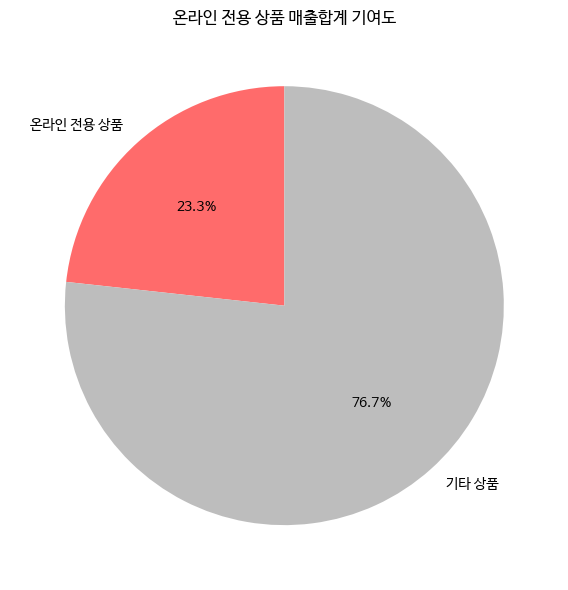

In [21]:
online_sales = df.loc[0, '온라인전용매출합계']
etc_sales = df.loc[0, '총매출합계'] - online_sales

plt.figure(figsize=(6, 6))

plt.pie(
    [online_sales, etc_sales],
    labels=['온라인 전용 상품', '기타 상품'],
    colors=['#FF6B6B', '#BDBDBD'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('온라인 전용 상품 매출합계 기여도')

plt.tight_layout()
plt.show()

## 4번 SQL

In [22]:
query = """
SELECT
    I.ITEM_ID,
    I.PRODUCT_NAME,
    SUM(O.SALES) AS 매출합계
FROM ITEM I
JOIN ORDER_INFO O
    ON I.ITEM_ID = O.ITEM_ID
GROUP BY
    I.ITEM_ID,
    I.PRODUCT_NAME
ORDER BY SUM(O.SALES) DESC
"""

df = pd.read_sql(query, conn)

df

,ITEM_ID,PRODUCT_NAME,매출합계
0,M0005,STEAK,9380000
1,M0001,SPECIAL_SET,5808000
2,M0006,SALAD_BAR,2075000
3,M0002,PASTA,1968000
4,M0003,PIZZA,1666000
5,M0004,SEA_FOOD,1625000
6,M0009,WINE,856000
7,M0008,SANDWICH,610000
8,M0007,SALAD,525000
9,M0010,JUICE,444000


/tmp/ipykernel_4159/2634022390.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


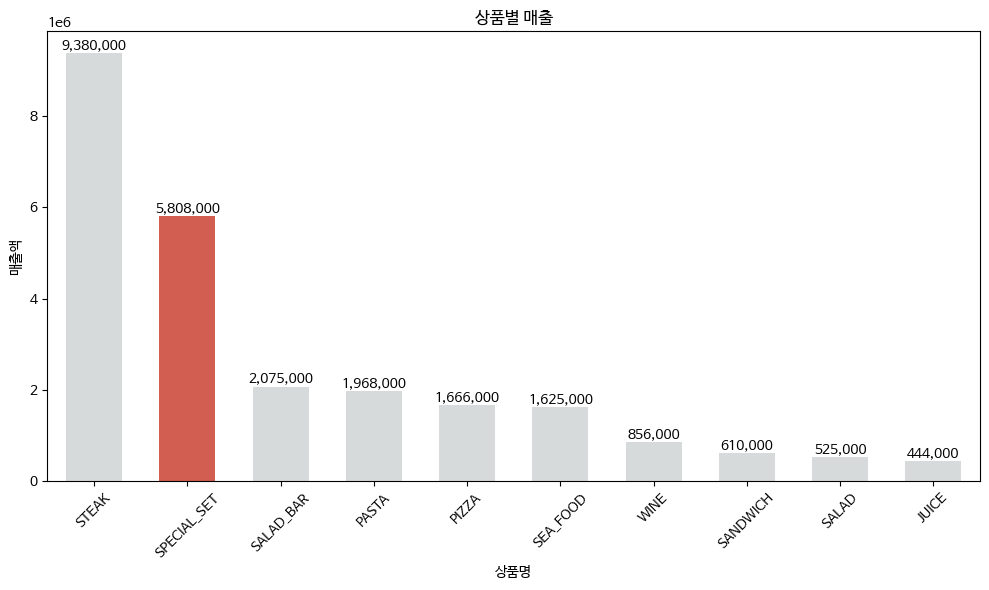

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = [
    '#E74C3C' if product == 'SPECIAL_SET'
    else '#D5DBDB'
    for product in df['PRODUCT_NAME']
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df,
    x='PRODUCT_NAME',
    y='매출합계',
    palette=colors
)

# 막대 두께 조절
for bar in ax.patches:
    current_width = bar.get_width()
    new_width = 0.6

    diff = current_width - new_width

    bar.set_width(new_width)
    bar.set_x(bar.get_x() + diff * 0.5)

for i, v in enumerate(df['매출합계']):
    ax.text(
        i,
        v,
        f'{v:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('상품별 매출')
plt.xlabel('상품명')
plt.ylabel('매출액')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 5번 SQL

In [24]:
query = """
SELECT
    SUBSTR(R.RESERV_DATE, 1, 6) AS MONTH,

    SUM(CASE WHEN I.PRODUCT_NAME = 'SPECIAL_SET'
             THEN O.SALES ELSE 0 END) AS SPECIAL_SET,

    SUM(CASE WHEN I.PRODUCT_NAME = 'PASTA'
             THEN O.SALES ELSE 0 END) AS PASTA,

    SUM(CASE WHEN I.PRODUCT_NAME = 'PIZZA'
             THEN O.SALES ELSE 0 END) AS PIZZA,

    SUM(CASE WHEN I.PRODUCT_NAME = 'SEA_FOOD'
             THEN O.SALES ELSE 0 END) AS SEA_FOOD,

    SUM(CASE WHEN I.PRODUCT_NAME = 'STEAK'
             THEN O.SALES ELSE 0 END) AS STEAK,

    SUM(CASE WHEN I.PRODUCT_NAME = 'SALAD_BAR'
             THEN O.SALES ELSE 0 END) AS SALAD_BAR,

    SUM(CASE WHEN I.PRODUCT_NAME = 'SALAD'
             THEN O.SALES ELSE 0 END) AS SALAD,

    SUM(CASE WHEN I.PRODUCT_NAME = 'SANDWICH'
             THEN O.SALES ELSE 0 END) AS SANDWICH,

    SUM(CASE WHEN I.PRODUCT_NAME = 'WINE'
             THEN O.SALES ELSE 0 END) AS WINE,

    SUM(CASE WHEN I.PRODUCT_NAME = 'JUICE'
             THEN O.SALES ELSE 0 END) AS JUICE

FROM RESERVATION R
JOIN ORDER_INFO O
    ON R.RESERV_NO = O.RESERV_NO
JOIN ITEM I
    ON O.ITEM_ID = I.ITEM_ID

GROUP BY SUBSTR(R.RESERV_DATE, 1, 6)
ORDER BY MONTH
"""

df = pd.read_sql(query, conn)

df

,MONTH,SPECIAL_SET,PASTA,PIZZA,SEA_FOOD,STEAK,SALAD_BAR,SALAD,SANDWICH,WINE,JUICE
0,201706,144000,24000,0,0,385000,0,30000,10000,8000,12000
1,201707,408000,228000,102000,175000,525000,200000,0,70000,0,36000
2,201708,336000,108000,136000,225000,455000,175000,15000,90000,40000,42000
3,201709,264000,120000,238000,300000,280000,200000,90000,30000,16000,48000
4,201710,552000,336000,391000,200000,1120000,425000,135000,40000,32000,102000
5,201711,888000,492000,544000,425000,1715000,400000,105000,150000,304000,174000
6,201712,3216000,660000,255000,300000,4900000,675000,150000,220000,456000,30000


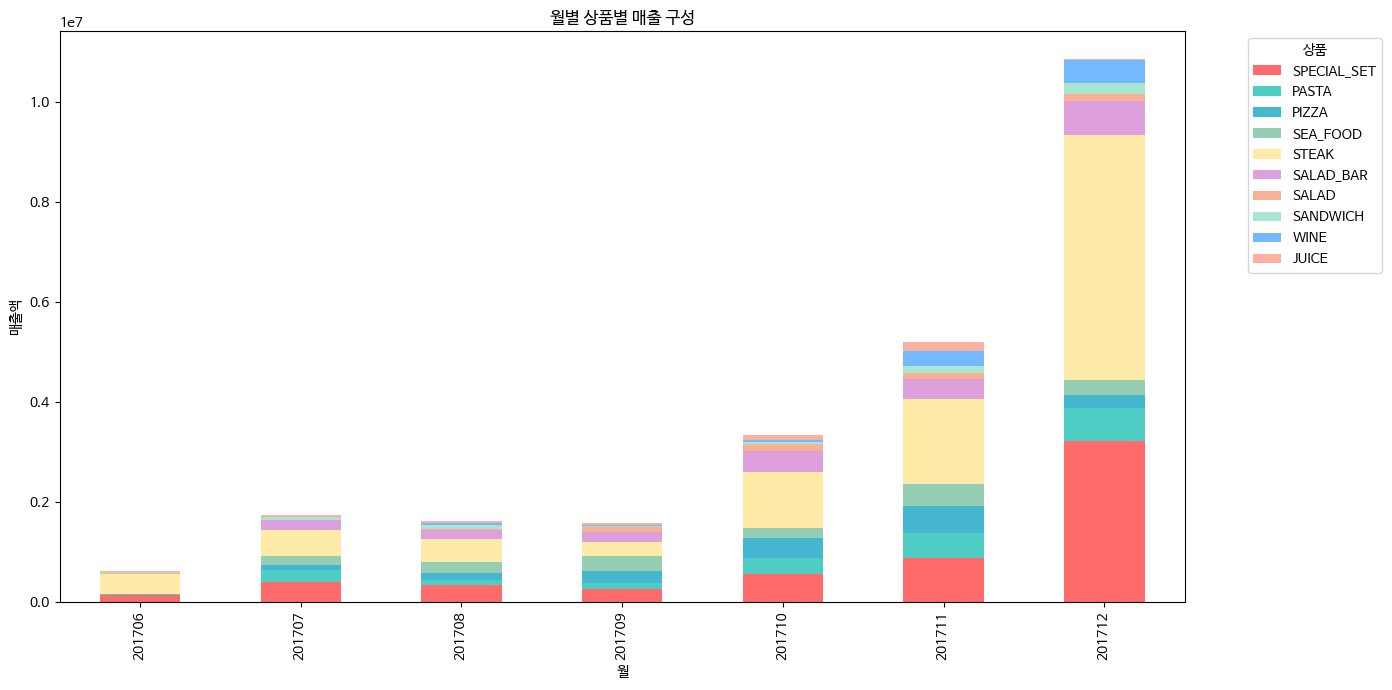

In [25]:
import matplotlib.pyplot as plt

df_plot = df.set_index('MONTH')

colors = [
    '#FF6B6B',  # SPECIAL_SET (강조)
    '#4ECDC4',  # PASTA
    '#45B7D1',  # PIZZA
    '#96CEB4',  # SEA_FOOD
    '#FFEAA7',  # STEAK
    '#DDA0DD',  # SALAD_BAR
    '#F8B195',  # SALAD
    '#A8E6CF',  # SANDWICH
    '#74B9FF',  # WINE
    '#FAB1A0'   # JUICE
]

ax = df_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    color=colors
)

plt.title('월별 상품별 매출 구성')
plt.xlabel('월')
plt.ylabel('매출액')

plt.legend(
    title='상품',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

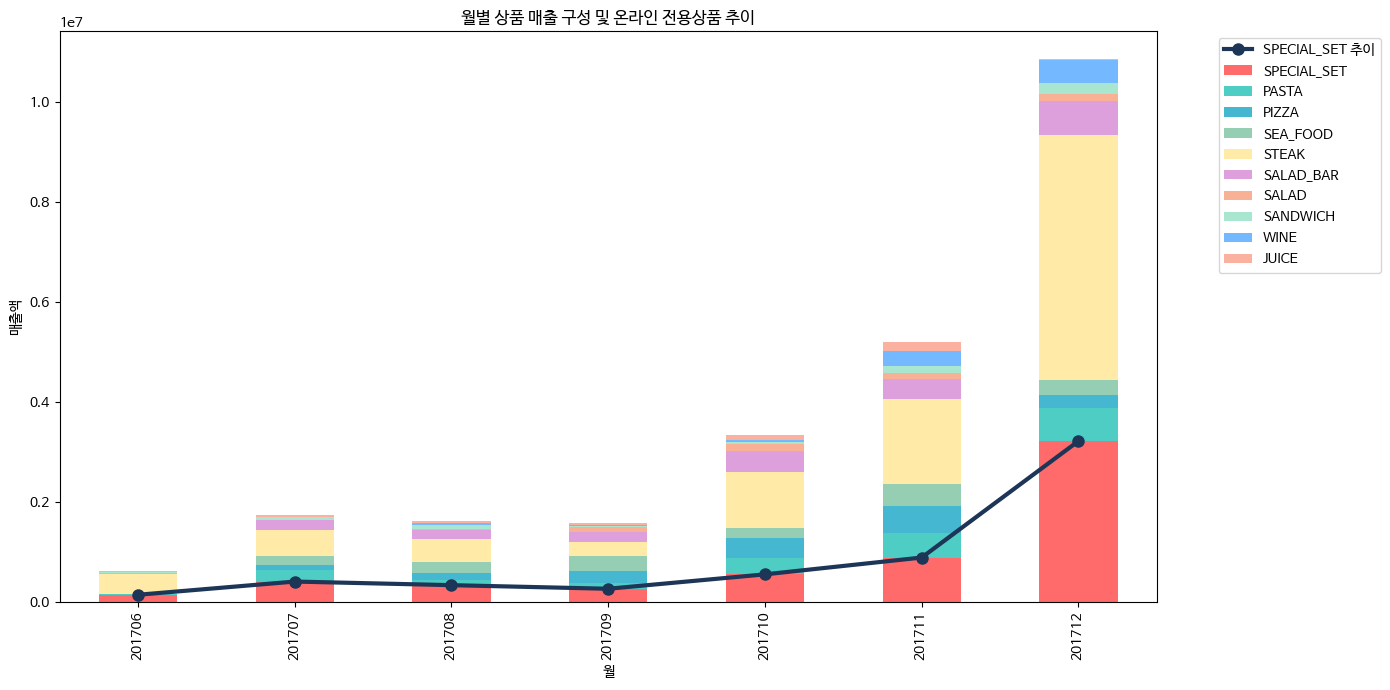

In [26]:
colors = [
    '#FF6B6B',  # SPECIAL_SET (강조)
    '#4ECDC4',  # PASTA
    '#45B7D1',  # PIZZA
    '#96CEB4',  # SEA_FOOD
    '#FFEAA7',  # STEAK
    '#DDA0DD',  # SALAD_BAR
    '#F8B195',  # SALAD
    '#A8E6CF',  # SANDWICH
    '#74B9FF',  # WINE
    '#FAB1A0'   # JUICE
]

import matplotlib.pyplot as plt

df_plot = df.set_index('MONTH')

fig, ax = plt.subplots(figsize=(14, 7))

# 누적 막대그래프
df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors
)

# SPECIAL_SET 추이 선
ax.plot(
    range(len(df_plot)),
    df_plot['SPECIAL_SET'],
    marker='o',
    linewidth=3,
    color='#1D3557',   # 진한 남색
    markersize=8,
    label='SPECIAL_SET 추이'
)

plt.title('월별 상품 매출 구성 및 온라인 전용상품 추이')
plt.xlabel('월')
plt.ylabel('매출액')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## 7번 SQL

In [27]:
query = """
SELECT
    SUBSTR(R.RESERV_DATE, 1, 6) AS 년월,

    SUM(CASE
            WHEN I.PRODUCT_DESC <> '온라인_전용상품'
            THEN O.SALES
            ELSE 0
        END) AS ETC,

    SUM(CASE
            WHEN I.PRODUCT_DESC = '온라인_전용상품'
            THEN O.SALES
            ELSE 0
        END) AS SPECIAL_SET,

    ROUND(
        SUM(CASE
                WHEN I.PRODUCT_DESC = '온라인_전용상품'
                THEN O.SALES
                ELSE 0
            END)
        * 100.0
        / SUM(O.SALES)
    , 1) AS 매출기여율

FROM RESERVATION R
JOIN ORDER_INFO O
    ON R.RESERV_NO = O.RESERV_NO
JOIN ITEM I
    ON O.ITEM_ID = I.ITEM_ID

GROUP BY SUBSTR(R.RESERV_DATE, 1, 6)
ORDER BY 년월
"""

df = pd.read_sql(query, conn)

df

,년월,ETC,SPECIAL_SET,매출기여율
0,201706,469000,144000,23.5
1,201707,1336000,408000,23.4
2,201708,1286000,336000,20.7
3,201709,1322000,264000,16.6
4,201710,2781000,552000,16.6
5,201711,4309000,888000,17.1
6,201712,7646000,3216000,29.6


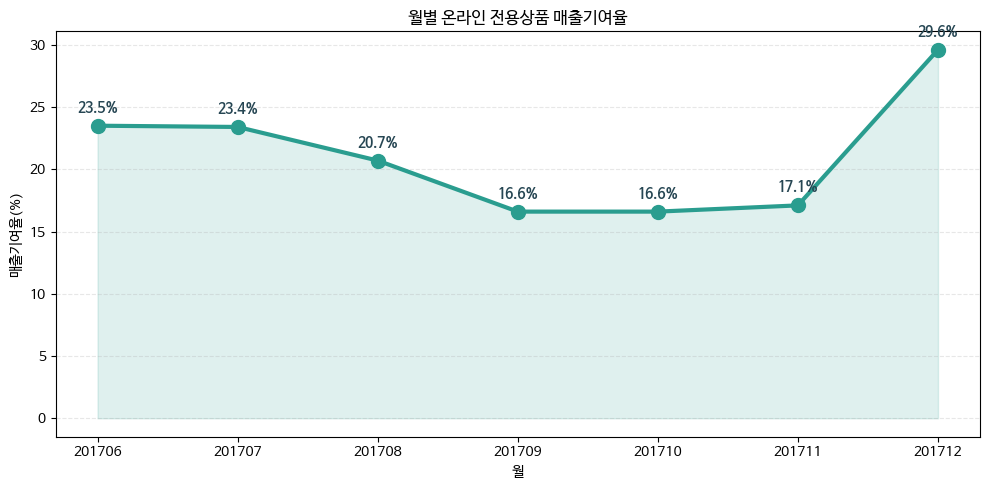

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    df['년월'],
    df['매출기여율'],
    marker='o',
    linewidth=3,
    color='#2A9D8F',
    markersize=10
)

plt.fill_between(
    df['년월'],
    df['매출기여율'],
    alpha=0.15,
    color='#2A9D8F'
)

for x, y in zip(df['년월'], df['매출기여율']):
    plt.text(
        x,
        y + 0.8,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        color='#264653',
        fontweight='bold'
    )

plt.title('월별 온라인 전용상품 매출기여율')
plt.xlabel('월')
plt.ylabel('매출기여율(%)')

plt.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

plt.tight_layout()
plt.show()

## 9번 SQL

In [29]:
query = """
SELECT
    SUBSTR(RESERV_DATE, 1, 6) AS 년월,
    COUNT(*) AS 총예약건,
    SUM(CASE WHEN CANCEL = 'N' THEN 1 ELSE 0 END) AS 예약완료건,
    SUM(CASE WHEN CANCEL = 'Y' THEN 1 ELSE 0 END) AS 예약취소건,
    ROUND(
        SUM(CASE WHEN CANCEL = 'Y' THEN 1 ELSE 0 END)
        * 100.0
        / COUNT(*)
    , 1) AS 예약취소율
FROM RESERVATION
GROUP BY SUBSTR(RESERV_DATE, 1, 6)
ORDER BY 년월
"""

df = pd.read_sql(query, conn)

df

,년월,총예약건,예약완료건,예약취소건,예약취소율
0,201706,11,9,2,18.2
1,201707,33,27,6,18.2
2,201708,39,33,6,15.4
3,201709,37,32,5,13.5
4,201710,55,47,8,14.5
5,201711,81,69,12,14.8
6,201712,140,120,20,14.3


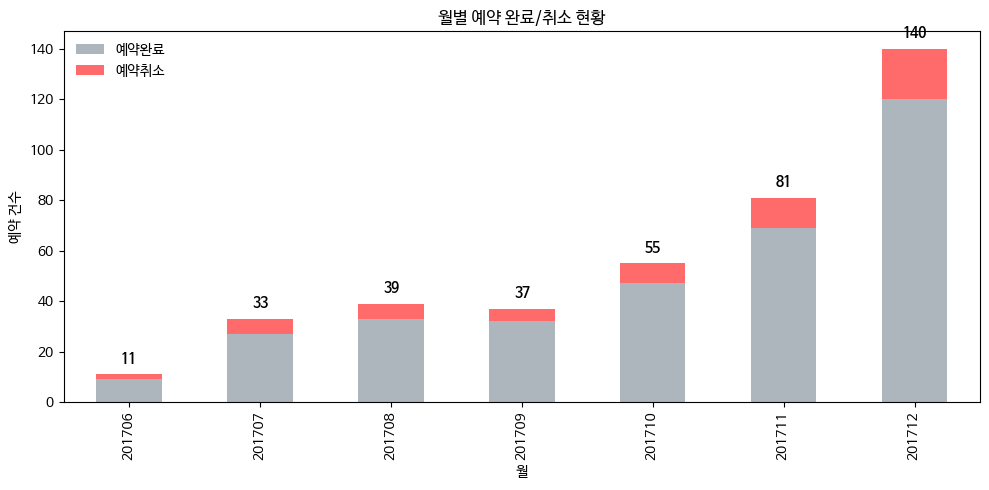

In [30]:
import matplotlib.pyplot as plt

df_plot = df.set_index('년월')

ax = df_plot[['예약완료건', '예약취소건']].plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=['#ADB5BD', '#FF6B6B']  # 완료=회색, 취소=빨강
)

for i, total in enumerate(df_plot['총예약건']):
    ax.text(
        i,
        total + 3,
        f'{total}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('월별 예약 완료/취소 현황')
plt.xlabel('월')
plt.ylabel('예약 건수')

plt.legend(
    ['예약완료', '예약취소'],
    frameon=False
)

plt.tight_layout()
plt.show()

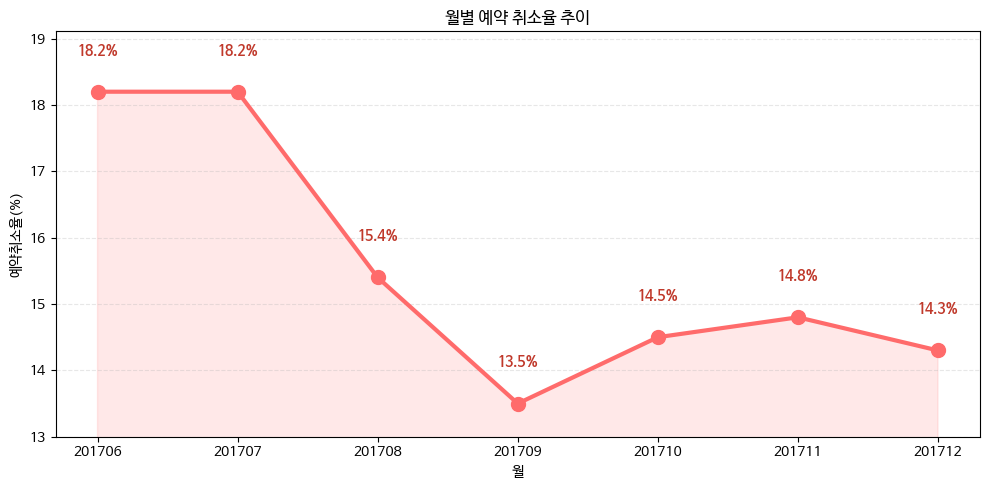

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    df['년월'],
    df['예약취소율'],
    marker='o',
    linewidth=3,
    color='#FF6B6B',
    markersize=10
)

plt.fill_between(
    df['년월'],
    df['예약취소율'],
    alpha=0.15,
    color='#FF6B6B'
)

for x, y in zip(df['년월'], df['예약취소율']):
    plt.text(
        x,
        y + 0.5,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        color='#C0392B',
        fontweight='bold'
    )

plt.title('월별 예약 취소율 추이')
plt.xlabel('월')
plt.ylabel('예약취소율(%)')

plt.ylim(bottom=13)

plt.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

plt.tight_layout()
plt.show()

## 10번 SQL

In [32]:
query = """
SELECT
    년월,
    'SPECIAL_SET' AS 상품명,

    SUM(CASE WHEN 요일번호='0' THEN SALES ELSE 0 END) AS 일요일,
    SUM(CASE WHEN 요일번호='1' THEN SALES ELSE 0 END) AS 월요일,
    SUM(CASE WHEN 요일번호='2' THEN SALES ELSE 0 END) AS 화요일,
    SUM(CASE WHEN 요일번호='3' THEN SALES ELSE 0 END) AS 수요일,
    SUM(CASE WHEN 요일번호='4' THEN SALES ELSE 0 END) AS 목요일,
    SUM(CASE WHEN 요일번호='5' THEN SALES ELSE 0 END) AS 금요일,
    SUM(CASE WHEN 요일번호='6' THEN SALES ELSE 0 END) AS 토요일

FROM (
    SELECT
        SUBSTR(R.RESERV_DATE,1,6) AS 년월,

        strftime(
            '%w',
            SUBSTR(R.RESERV_DATE,1,4) || '-' ||
            SUBSTR(R.RESERV_DATE,5,2) || '-' ||
            SUBSTR(R.RESERV_DATE,7,2)
        ) AS 요일번호,

        O.SALES

    FROM RESERVATION R
    JOIN ORDER_INFO O
        ON R.RESERV_NO = O.RESERV_NO
    JOIN ITEM I
        ON O.ITEM_ID = I.ITEM_ID

    WHERE I.PRODUCT_DESC = '온라인_전용상품'
)

GROUP BY 년월
ORDER BY 년월
"""

df = pd.read_sql(query, conn)

df

,년월,상품명,일요일,월요일,화요일,수요일,목요일,금요일,토요일
0,201706,SPECIAL_SET,48000,0,0,48000,48000,0,0
1,201707,SPECIAL_SET,0,0,48000,96000,0,0,264000
2,201708,SPECIAL_SET,96000,0,24000,72000,72000,72000,0
3,201709,SPECIAL_SET,96000,0,48000,0,0,96000,24000
4,201710,SPECIAL_SET,120000,72000,168000,96000,96000,0,0
5,201711,SPECIAL_SET,168000,168000,264000,48000,48000,0,192000
6,201712,SPECIAL_SET,432000,48000,672000,600000,576000,72000,816000


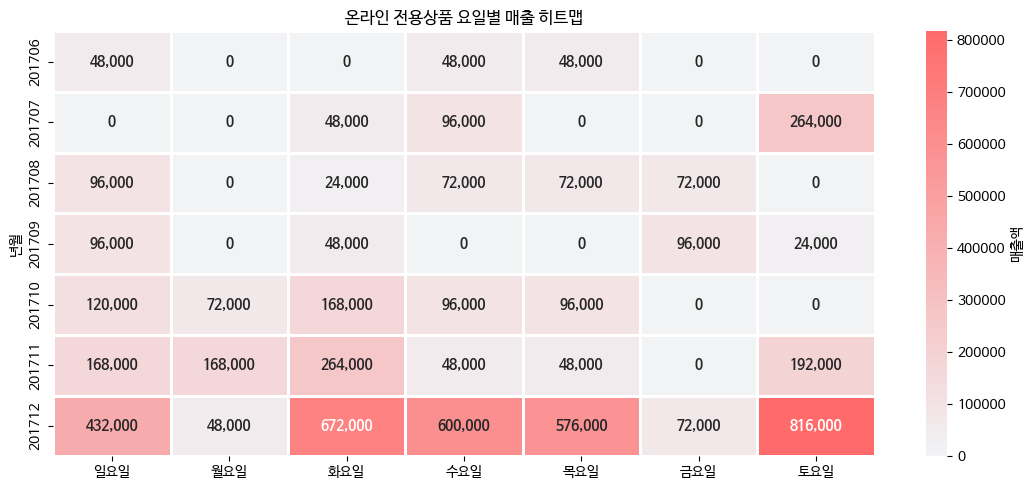

In [33]:
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = df.set_index('년월')[
    ['일요일', '월요일', '화요일', '수요일', '목요일', '금요일', '토요일']
]

custom_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    ['#F1F3F5', '#FF6B6B']
)

plt.figure(figsize=(11, 5))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=',.0f',
    cmap=custom_cmap,
    linewidths=1,
    linecolor='white',
    annot_kws={
        'size': 10,
        'weight': 'bold'
    },
    cbar_kws={'label': '매출액'}
)

plt.title('온라인 전용상품 요일별 매출 히트맵')

plt.xlabel('')
plt.ylabel('년월')

plt.tight_layout()
plt.show()

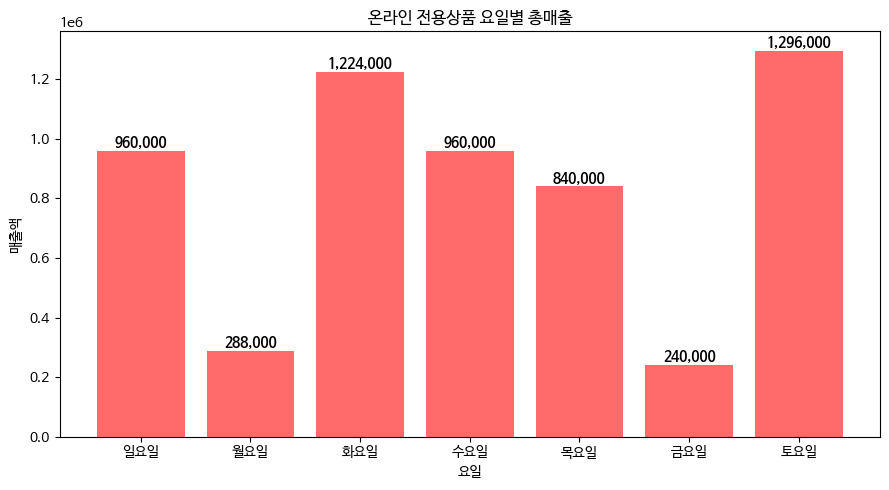

In [35]:
day_sales_df = day_sales.reset_index()
day_sales_df.columns = ['요일', '매출액']

plt.figure(figsize=(9, 5))

plt.bar(
    day_sales_df['요일'],
    day_sales_df['매출액'],
    color='#FF6B6B'
)

for i, v in enumerate(day_sales_df['매출액']):
    plt.text(
        i,
        v,
        f'{v:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('온라인 전용상품 요일별 총매출')
plt.xlabel('요일')
plt.ylabel('매출액')

plt.tight_layout()
plt.show()

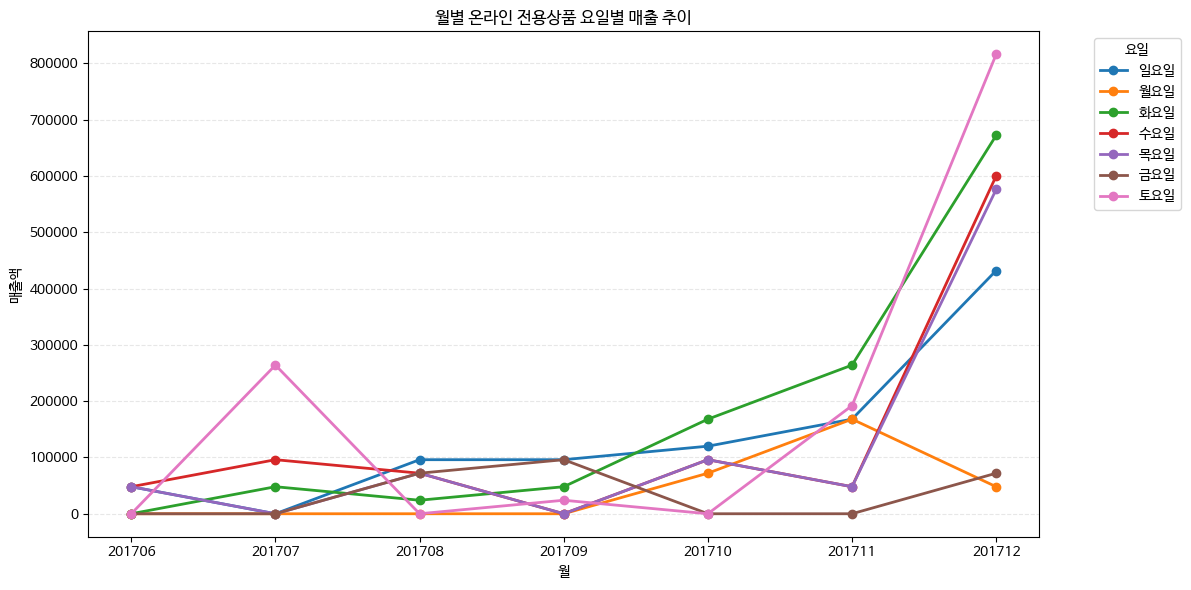

In [36]:
df_line = df.set_index('년월')[days]

plt.figure(figsize=(12, 6))

for day in days:
    plt.plot(
        df_line.index,
        df_line[day],
        marker='o',
        linewidth=2,
        label=day
    )

plt.title('월별 온라인 전용상품 요일별 매출 추이')
plt.xlabel('월')
plt.ylabel('매출액')

plt.legend(
    title='요일',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

plt.tight_layout()
plt.show()

## 11번 SQL

In [37]:
query = """
SELECT *
FROM (
    SELECT
        SUBSTR(R.RESERV_DATE, 1, 6) AS 년월,
        R.BRANCH AS 지점,
        SUM(O.SALES) AS 매출액,

        RANK() OVER (
            PARTITION BY SUBSTR(R.RESERV_DATE, 1, 6)
            ORDER BY SUM(O.SALES) DESC
        ) AS 순위

    FROM RESERVATION R
    JOIN ORDER_INFO O
        ON R.RESERV_NO = O.RESERV_NO
    JOIN ITEM I
        ON O.ITEM_ID = I.ITEM_ID

    WHERE I.PRODUCT_DESC = '온라인_전용상품'

    GROUP BY
        SUBSTR(R.RESERV_DATE, 1, 6),
        R.BRANCH
)
WHERE 순위 <= 3
ORDER BY 년월, 순위
"""

df = pd.read_sql(query, conn)

df

,년월,지점,매출액,순위
0,201706,종로,48000,1
1,201706,영등포,48000,1
2,201706,강남,48000,1
3,201707,종로,96000,1
4,201707,관악,96000,1
5,201707,서대문,72000,3
6,201708,마포,168000,1
7,201708,강남,96000,2
8,201708,강북,72000,3
9,201709,종로,96000,1


In [38]:
!pip install folium

In [39]:
import folium

# 서울 구청 기준 대략 좌표
branch_coords = {
    '강남': [37.5172, 127.0473],
    '강북': [37.6396, 127.0257],
    '관악': [37.4784, 126.9516],
    '금천': [37.4569, 126.8955],
    '노원': [37.6542, 127.0568],
    '마포': [37.5663, 126.9019],
    '서대문': [37.5791, 126.9368],
    '송파': [37.5145, 127.1059],
    '영등포': [37.5264, 126.8963],
    '용산': [37.5326, 126.9905],
    '종로': [37.5735, 126.9788]
}

In [41]:
query = """
SELECT
    R.BRANCH AS 지점,
    SUM(O.SALES) AS 매출액,
    RANK() OVER (
        ORDER BY SUM(O.SALES) DESC
    ) AS 순위

FROM RESERVATION R
JOIN ORDER_INFO O
    ON R.RESERV_NO = O.RESERV_NO
JOIN ITEM I
    ON O.ITEM_ID = I.ITEM_ID

WHERE I.PRODUCT_DESC = '온라인_전용상품'

GROUP BY R.BRANCH
ORDER BY 순위
"""

df_rank = pd.read_sql(query, conn)

df_rank

,지점,매출액,순위
0,강남,1416000,1
1,종로,744000,2
2,영등포,672000,3
3,송파,432000,4
4,서초,312000,5
5,구로,312000,5
6,중구,264000,7
7,마포,264000,7
8,용산,216000,9
9,관악,168000,10


In [43]:
import folium

rank_colors = {
    1: '#C0392B',  # 진한 빨강
    2: '#FF6B6B',  # 중간 빨강
    3: '#FFB3B3'   # 연한 빨강
}

m = folium.Map(
    location=[37.5665, 126.9780],
    zoom_start=11,
    tiles='CartoDB positron'
)

for _, row in df_rank.iterrows():

    branch = row['지점']
    rank = int(row['순위'])
    sales = row['매출액']

    if branch in branch_coords:

        # 색상 설정
        if rank <= 3:
            color = rank_colors[rank]
            opacity = 0.85
        else:
            color = '#A6A6A6'
            opacity = 0.5

        # 버블
        folium.CircleMarker(
            location=branch_coords[branch],
            radius=max(8, sales / 24000),
            popup=f"""
            {branch}<br>
            매출액: {sales:,.0f}원<br>
            순위: {rank}위
            """,
            tooltip=f"{rank}위 {branch}",
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            weight=2
        ).add_to(m)

        # 라벨
        if rank <= 3:
            label_html = f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                color:white;
                white-space:nowrap;
                text-shadow:
                    1px 1px 2px black,
                    -1px -1px 2px black,
                    1px -1px 2px black,
                    -1px 1px 2px black;
                transform: translate(-15px, -7px);
            ">
            {rank}위 {branch}
            </div>
            """
        else:
            label_html = f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                color:black;
                white-space:nowrap;
                transform: translate(10px, -10px);
            ">
            {rank}위 {branch}
            </div>
            """

        folium.Marker(
            location=branch_coords[branch],
            icon=folium.DivIcon(html=label_html)
        ).add_to(m)

m

In [44]:
import folium

rank_colors = {
    1: '#C0392B',  # 진한 빨강
    2: '#FF6B6B',  # 중간 빨강
    3: '#FFB3B3'   # 연한 빨강
}

m = folium.Map(
    location=[37.55, 127.00],
    zoom_start=12,
    tiles='CartoDB positron'
)

for _, row in df_rank.iterrows():

    branch = row['지점']
    rank = int(row['순위'])
    sales = row['매출액']

    if branch in branch_coords:

        # 색상 설정
        if rank <= 3:
            color = rank_colors[rank]
            opacity = 0.85
        else:
            color = '#A6A6A6'
            opacity = 0.5

        # 버블
        folium.CircleMarker(
            location=branch_coords[branch],
            radius=max(8, sales / 20000),
            popup=f"""
            {branch}<br>
            매출액: {sales:,.0f}원<br>
            순위: {rank}위
            """,
            tooltip=f"{rank}위 {branch}",
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            weight=2
        ).add_to(m)

        # 라벨
        if rank <= 3:
            label_html = f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                color:white;
                white-space:nowrap;
                text-shadow:
                    1px 1px 2px black,
                    -1px -1px 2px black,
                    1px -1px 2px black,
                    -1px 1px 2px black;
                transform: translate(-15px, -7px);
            ">
            {rank}위 {branch}
            </div>
            """
        else:
            label_html = f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                color:black;
                white-space:nowrap;
                transform: translate(10px, -10px);
            ">
            {rank}위 {branch}
            </div>
            """

        folium.Marker(
            location=branch_coords[branch],
            icon=folium.DivIcon(html=label_html)
        ).add_to(m)

# 서울 영역만 보이도록 강제
m.fit_bounds([
    [37.44, 126.83],  # 남서쪽
    [37.70, 127.18]   # 북동쪽
])

m

In [46]:
m.save('seoul_sales_map.html')